# EchoROI: Inference Demo

This notebook demonstrates how to use the **echoroi** package for:
1. Loading the pretrained model
2. Predicting ROI masks on echocardiogram images
3. Extracting the ROI crop
4. De-identifying images (masking outside the ROI)

**Hardware:** Apple Mac mini (M2 Pro, 16 GB unified memory), macOS Sequoia 15.3

---

> **User note — macOS (Apple Silicon)**
>
> The `tensorflow-metal` GPU plugin can deadlock inside Jupyter kernels
> on certain macOS / Apple Silicon configurations.  The setup cell below
> explicitly disables GPU devices so that all TensorFlow operations run
> on the CPU.  Inference on 256 × 256 images takes < 1 s per frame on
> CPU, so this has no practical impact on the demo.  If you are running
> on Linux or Windows with CUDA you may remove the
> `tf.config.set_visible_devices([], "GPU")` call to use your GPU.

## 1. Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Force CPU-only mode ─────────────────────────────────────────────────
# The tensorflow-metal GPU plugin can deadlock inside Jupyter kernels on
# macOS (Apple Silicon).  Disabling GPU devices before any TF operation
# avoids the hang.  CPU inference on 256×256 images is fast (<1 s).
# If you are on Linux/Windows with CUDA you can comment out these lines.
import tensorflow as tf
try:
    tf.config.set_visible_devices([], "GPU")
    print("GPU devices disabled — running on CPU")
except RuntimeError as e:
    print(f"Note: {e}")

# Navigate to project root regardless of how the kernel was launched
notebook_dir = Path(os.path.abspath("")).resolve()
if notebook_dir.name == "notebooks":
    os.chdir(notebook_dir.parent)
elif not (notebook_dir / "models").exists():
    # Try one level up
    if (notebook_dir.parent / "models").exists():
        os.chdir(notebook_dir.parent)

assert Path("models/echoroi_unified.keras").exists(), "Model not found — check working directory"

from echoroi.inference import UNetPredictor
print("echoroi loaded successfully")

GPU devices disabled — running on CPU
echoroi loaded successfully


## 2. Load Pretrained Model

The `UNetPredictor` class handles model loading and provides a simple inference API.

In [2]:
predictor = UNetPredictor("models/echoroi_unified.keras")  # ~10-15 s on first load (CPU mode)
print(f"Model loaded: {predictor.model.count_params():,} parameters")

Loading model from: models/echoroi_unified.keras
Model loaded successfully!
Model loaded: 31,030,593 parameters


## 3. Single Image Prediction

Predict the ROI mask for a single echocardiogram image.

Input: data/images/0X1AACBE51D95E0698.png
Mask shape: (256, 256), dtype: uint8


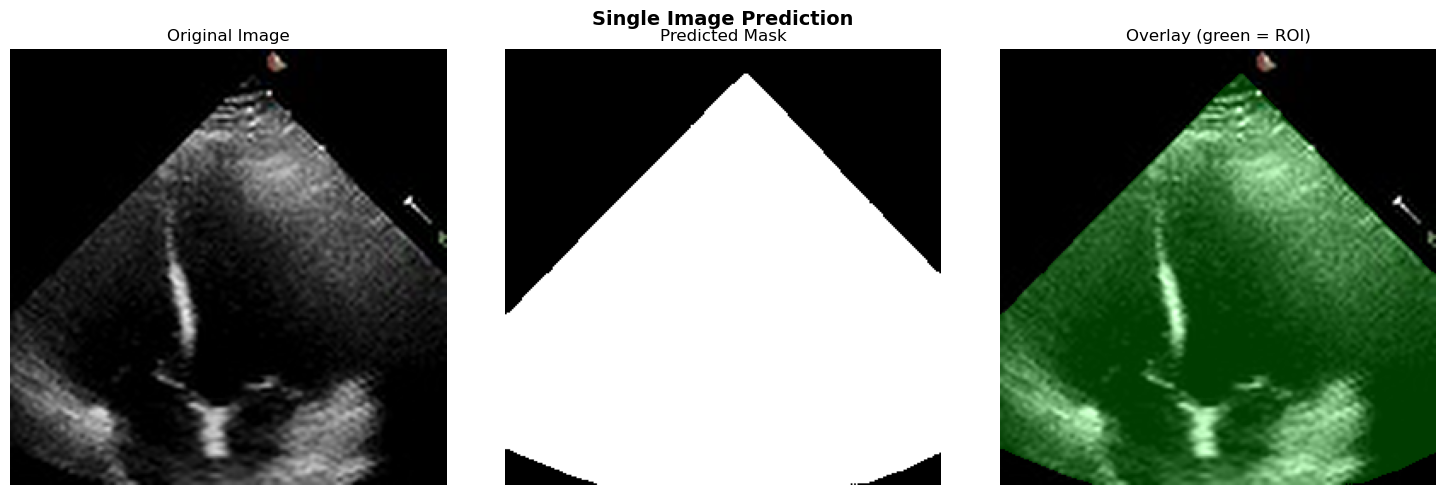

In [3]:
import glob
import cv2

# Pick a sample image
sample_images = sorted(glob.glob("data/images/*.png"))
sample_path = sample_images[42]  # Arbitrary sample
print(f"Input: {sample_path}")

# Predict mask + get original for visualization
mask, original = predictor.predict_single_image(
    sample_path, threshold=0.5, return_original=True
)
print(f"Mask shape: {mask.shape}, dtype: {mask.dtype}")

# Resize original to model input size (matches mask dimensions)
original_resized = predictor.preprocessor.resize_with_padding(original)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_resized, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Predicted Mask')
axes[1].axis('off')

# Overlay: green tint on ROI
if original_resized.ndim == 2:
    overlay = cv2.cvtColor(original_resized, cv2.COLOR_GRAY2RGB)
else:
    overlay = original_resized.copy()
overlay_mask = (mask > 127).astype(np.uint8)
overlay[..., 1] = np.clip(
    overlay[..., 1].astype(np.int32) + overlay_mask * 60, 0, 255
).astype(np.uint8)
axes[2].imshow(overlay)
axes[2].set_title('Overlay (green = ROI)')
axes[2].axis('off')

plt.suptitle('Single Image Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. ROI Extraction

Crop the image to just the detected ROI region.

ROI crop shape: (251, 256, 3)


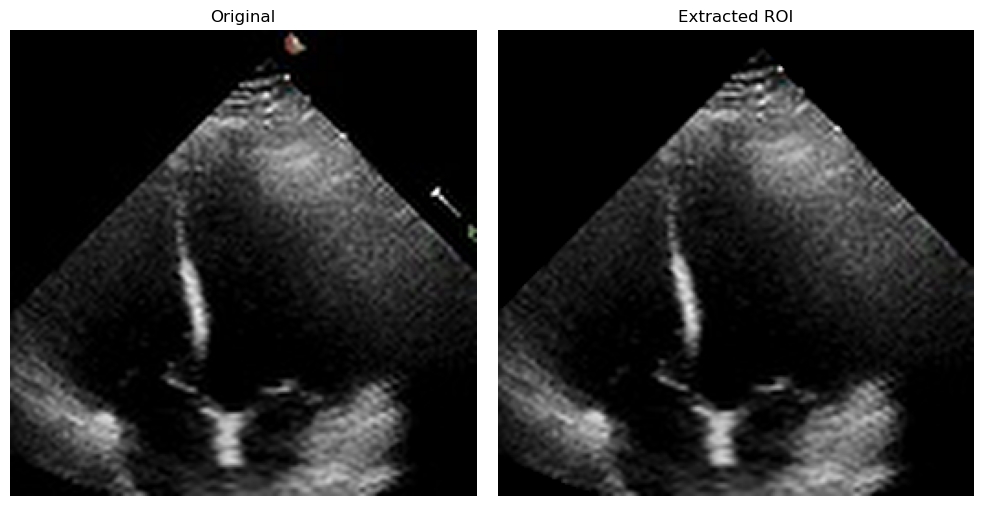

In [4]:
# extract_roi takes (image_array, mask_array, padding)
roi_crop = predictor.extract_roi(original_resized, mask, padding=10)
print(f"ROI crop shape: {roi_crop.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_resized, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(roi_crop, cmap='gray')
axes[1].set_title('Extracted ROI')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. De-identification

Mask everything outside the ROI to remove patient identification information
(text overlays, ECG traces, institutional logos).

De-identified shape: (256, 256, 3)


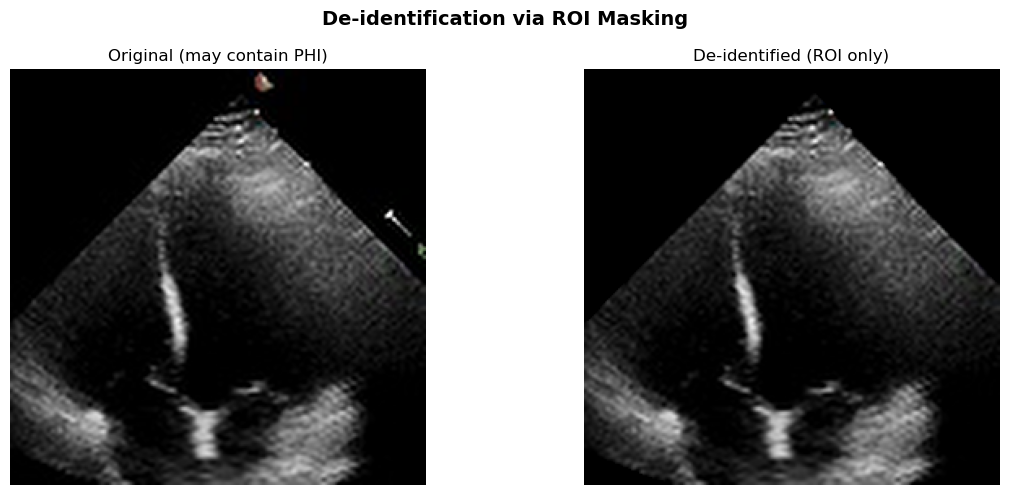

In [5]:
# apply_mask_for_deidentification takes (image_array, mask_array)
deidentified = predictor.apply_mask_for_deidentification(original_resized, mask, mask_value=0)
print(f"De-identified shape: {deidentified.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_resized, cmap='gray')
axes[0].set_title('Original (may contain PHI)')
axes[0].axis('off')

axes[1].imshow(deidentified, cmap='gray')
axes[1].set_title('De-identified (ROI only)')
axes[1].axis('off')

plt.suptitle('De-identification via ROI Masking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Batch Processing

Process multiple images and display results.

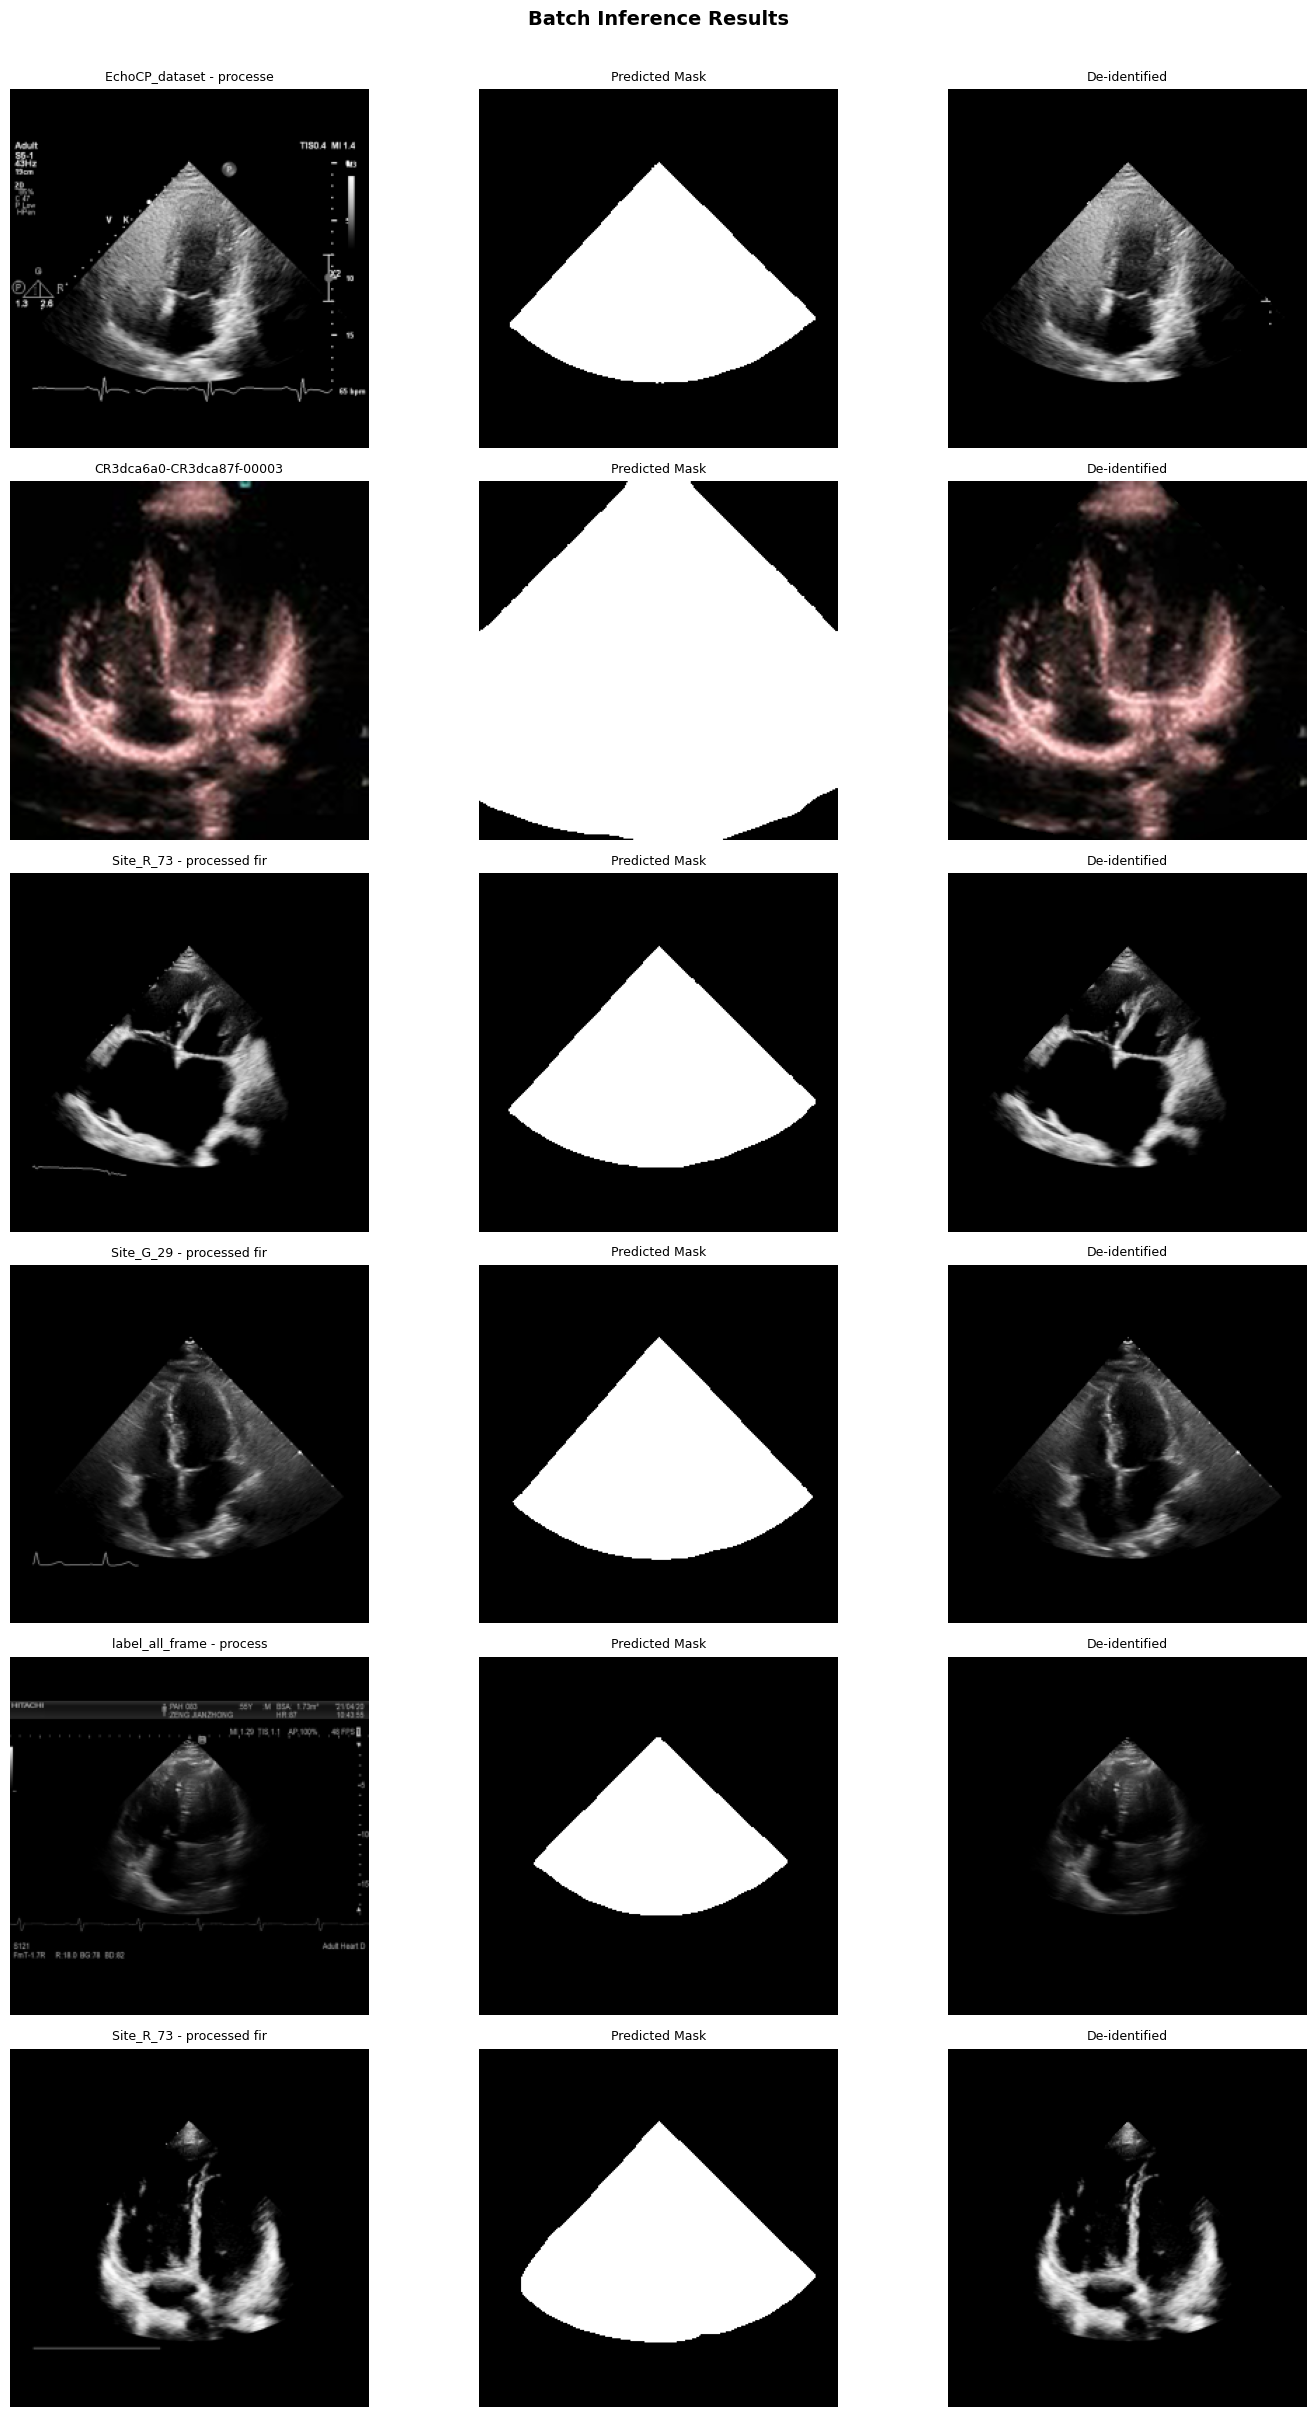

In [12]:
import random

# Random 6 samples each run — re-run to get examples you like
batch_images = random.sample(sample_images, min(6, len(sample_images)))

fig, axes = plt.subplots(len(batch_images), 3, figsize=(15, 4 * len(batch_images)))

for i, img_path in enumerate(batch_images):
    pred_mask, orig = predictor.predict_single_image(img_path, return_original=True)
    orig_resized = predictor.preprocessor.resize_with_padding(orig)
    deident = predictor.apply_mask_for_deidentification(orig_resized, pred_mask)

    axes[i, 0].imshow(orig_resized, cmap='gray')
    axes[i, 0].set_title(os.path.basename(img_path)[:25], fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(pred_mask, cmap='gray')
    axes[i, 1].set_title('Predicted Mask', fontsize=9)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(deident, cmap='gray')
    axes[i, 2].set_title('De-identified', fontsize=9)
    axes[i, 2].axis('off')

plt.suptitle('Batch Inference Results', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

## 7. Inference Speed

Benchmark single-image inference latency.

In [7]:
# benchmark_inference_speed takes (image_path, num_runs)
stats = predictor.benchmark_inference_speed(sample_path, num_runs=100)
print(f"\nMean latency:   {stats['mean_time']*1000:.1f} ms")
print(f"Std deviation:  {stats['std_time']*1000:.1f} ms")
print(f"Min latency:    {stats['min_time']*1000:.1f} ms")
print(f"Max latency:    {stats['max_time']*1000:.1f} ms")
print(f"Throughput:     {stats['fps']:.1f} FPS")

\nInference Speed Benchmark (100 runs):
  Mean time: 0.2566 ± 0.0155 seconds
  Min time: 0.2416 seconds
  Max time: 0.3091 seconds
  Average FPS: 3.90

Mean latency:   256.6 ms
Std deviation:  15.5 ms
Min latency:    241.6 ms
Max latency:    309.1 ms
Throughput:     3.9 FPS


## Summary

The `echoroi` package provides a simple API for cardiac ultrasound ROI segmentation:

```python
from echoroi.inference import UNetPredictor

predictor = UNetPredictor("models/echoroi_unified.keras")

# Predict mask (returns binary mask; use return_original=True to also get the input image)
mask = predictor.predict_single_image("image.png")
mask, original = predictor.predict_single_image("image.png", return_original=True)

# Extract ROI crop (takes arrays, not paths)
resized = predictor.preprocessor.resize_with_padding(original)
roi = predictor.extract_roi(resized, mask, padding=10)

# De-identify (mask everything outside ROI)
safe = predictor.apply_mask_for_deidentification(resized, mask)

# Benchmark
stats = predictor.benchmark_inference_speed("image.png", num_runs=100)
```

For ONNX deployment, see notebook 02. For CLI usage: `echoroi predict --help`

---
## 8. Generate Paper Figures

The cells below produce publication-quality figures for `paper/paper.md`.
All outputs are saved to `paper/figures/` at 300 dpi.

### Figure 1 — Pipeline Overview (4-panel)

`(a) Raw frame → (b) Predicted mask → (c) De-identified → (d) ROI crop`

Random sample index: 923  →  EchoCP_dataset - processed first frame_013_r_image.png


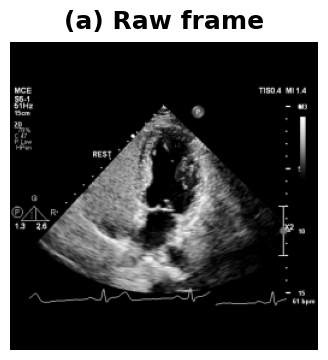

Saved → paper/figures/figure_1a.png


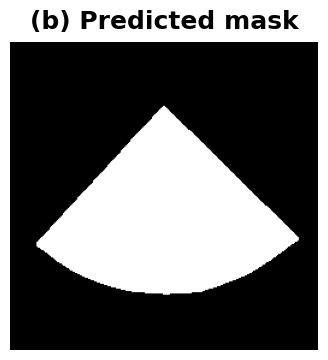

Saved → paper/figures/figure_1b.png


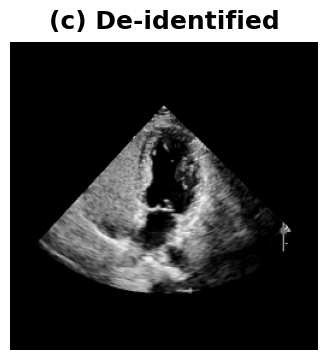

Saved → paper/figures/figure_1c.png


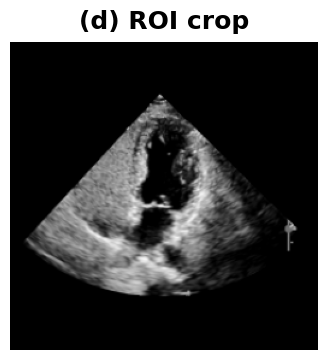

Saved → paper/figures/figure_1d.png

All four panels saved. Re-run for a different random sample.


In [136]:
import random

os.makedirs("paper/figures", exist_ok=True)

# Random sample each run — re-run until you get a frame you like
fig1_idx = random.randint(0, len(sample_images) - 1)
fig1_path = sample_images[fig1_idx]
print(f"Random sample index: {fig1_idx}  →  {os.path.basename(fig1_path)}")

fig1_mask, fig1_orig = predictor.predict_single_image(
    fig1_path, threshold=0.5, return_original=True
)
fig1_resized = predictor.preprocessor.resize_with_padding(fig1_orig)
fig1_deident = predictor.apply_mask_for_deidentification(fig1_resized, fig1_mask)
fig1_roi = predictor.extract_roi(fig1_resized, fig1_mask, padding=10)

# Pad ROI crop to same size as other panels (256x256), centred, black background
target_h, target_w = fig1_resized.shape[:2]
roi_h, roi_w = fig1_roi.shape[:2]
scale = min(target_h / roi_h, target_w / roi_w)
new_h, new_w = int(roi_h * scale), int(roi_w * scale)
roi_scaled = cv2.resize(fig1_roi, (new_w, new_h), interpolation=cv2.INTER_AREA)
roi_padded = np.zeros_like(fig1_resized)
y_off = (target_h - new_h) // 2
x_off = (target_w - new_w) // 2
roi_padded[y_off:y_off + new_h, x_off:x_off + new_w] = roi_scaled

# Save four separate images with titles sized for the paper (~14 pt equivalent)
panels = [
    (fig1_resized, "(a) Raw frame",      "figure_1a.png"),
    (fig1_mask,    "(b) Predicted mask",  "figure_1b.png"),
    (fig1_deident, "(c) De-identified",   "figure_1c.png"),
    (roi_padded,   "(d) ROI crop",        "figure_1d.png"),
]

for img, title, fname in panels:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=18, fontweight="bold", pad=10)
    ax.axis("off")
    fig.savefig(f"paper/figures/{fname}", dpi=300, bbox_inches="tight",
                facecolor="white")
    plt.show()
    print(f"Saved → paper/figures/{fname}")

print("\nAll four panels saved. Re-run for a different random sample.")

### Figure 3 — Prediction Samples Grid

Five columns of (input, ground-truth mask, predicted mask) spanning diverse frames.

Random sample indices: [353, 368, 590, 1106, 1198]


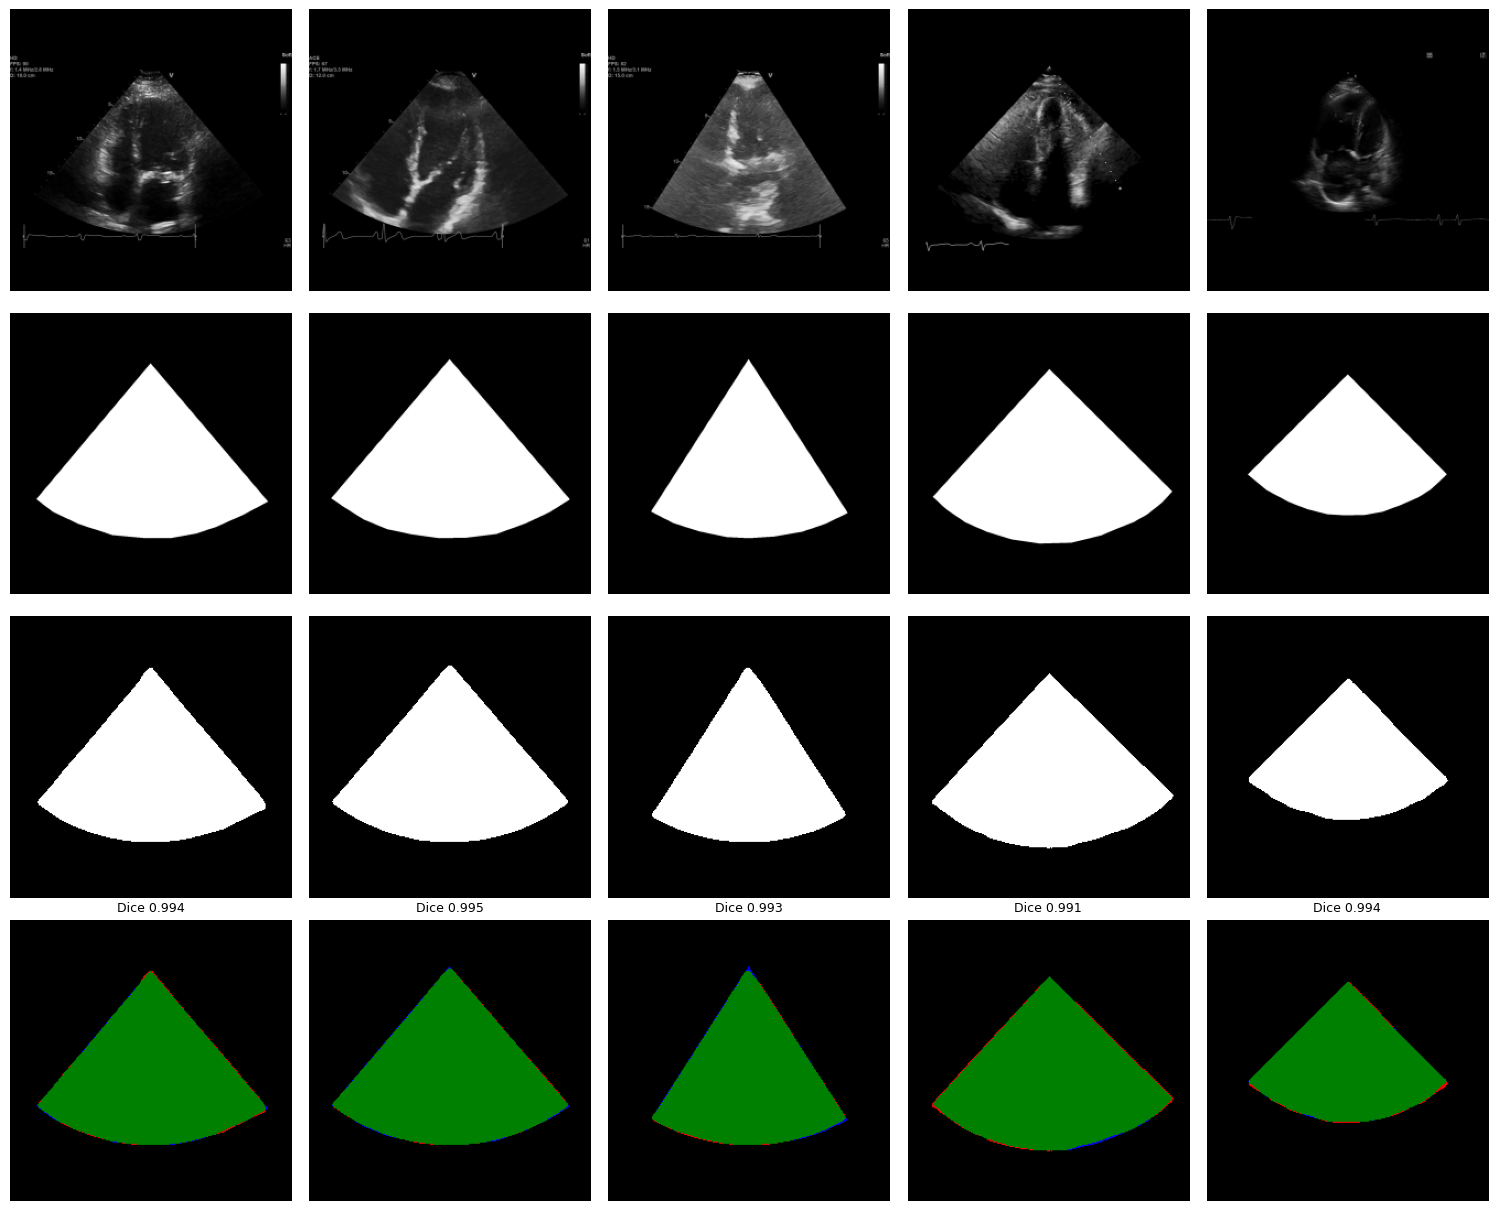

Saved → paper/figures/prediction_samples.png


In [137]:
# Gather matched image / mask pairs
mask_dir = "data/masks"
n_cols = 5

# Random diverse samples each run — re-run to get a spread you like
indices = sorted(random.sample(range(len(sample_images)), n_cols))
print(f"Random sample indices: {indices}")

fig, axes = plt.subplots(4, n_cols, figsize=(3.0 * n_cols, 12))
row_labels = ["Input", "GT Mask", "Predicted", "Difference"]

for col, idx in enumerate(indices):
    img_path = sample_images[idx]
    basename = os.path.basename(img_path)

    # Load ground-truth mask (same filename in masks/ folder)
    gt_path = os.path.join(mask_dir, basename)
    gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE) if os.path.exists(gt_path) else None

    # Predict
    pred_mask, orig = predictor.predict_single_image(img_path, return_original=True)
    orig_resized = predictor.preprocessor.resize_with_padding(orig)

    # Row 0: input
    axes[0, col].imshow(orig_resized, cmap="gray")
    axes[0, col].axis("off")

    # Row 1: ground-truth mask
    if gt_mask is not None:
        gt_resized = predictor.preprocessor.resize_with_padding(gt_mask)
        axes[1, col].imshow(gt_resized, cmap="gray")
    else:
        gt_resized = None
        axes[1, col].text(0.5, 0.5, "N/A", ha="center", va="center",
                          transform=axes[1, col].transAxes, fontsize=12)
    axes[1, col].axis("off")

    # Row 2: predicted mask
    axes[2, col].imshow(pred_mask, cmap="gray")
    axes[2, col].axis("off")

    # Row 3: difference map (red = FP, blue = FN, black = agreement)
    if gt_resized is not None:
        gt_bin = (gt_resized > 127).astype(np.uint8)
        pred_bin = (pred_mask > 127).astype(np.uint8)
        # Compute per-column Dice
        intersection = np.sum(gt_bin & pred_bin)
        dice = 2.0 * intersection / (np.sum(gt_bin) + np.sum(pred_bin) + 1e-8)

        diff_rgb = np.zeros((*gt_bin.shape, 3), dtype=np.uint8)
        diff_rgb[..., 0] = ((pred_bin == 1) & (gt_bin == 0)).astype(np.uint8) * 255  # FP → red
        diff_rgb[..., 2] = ((pred_bin == 0) & (gt_bin == 1)).astype(np.uint8) * 255  # FN → blue
        agree = ((pred_bin == 1) & (gt_bin == 1)).astype(np.uint8) * 128
        diff_rgb[..., 1] = agree  # TP → green
        axes[3, col].imshow(diff_rgb)
        axes[3, col].set_title(f"Dice {dice:.3f}", fontsize=9)
    else:
        axes[3, col].text(0.5, 0.5, "N/A", ha="center", va="center",
                          transform=axes[3, col].transAxes, fontsize=12)
    axes[3, col].axis("off")

# Row labels on leftmost column
for r, label in enumerate(row_labels):
    axes[r, 0].set_ylabel(label, fontsize=11, rotation=0, labelpad=55, va="center")

plt.tight_layout(pad=0.3)
fig.savefig("paper/figures/prediction_samples.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved → paper/figures/prediction_samples.png")

### Figure 2 — U-Net Architecture

Figure 2 (`figures/unet_architecture.png`) is a static architecture diagram.
Generate it manually using a drawing tool (draw.io, Lucidchart) or with
the model summary below for reference.

In [10]:
# Print model summary for architecture reference
predictor.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ dropout_2[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ dropout_3[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)